In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((24,24)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_dataset=datasets.MNIST(root='./data',train=True,download=True,transform=transform)

dataloader=torch.utils.data.DataLoader(train_dataset,batch_size=32,shuffle=True)

In [3]:
class Generator(nn.Module):
    def __init__(self,latent_dim,num_classes):
        super(Generator,self).__init__()
        self.model=nn.Sequential(
            nn.Linear(latent_dim+num_classes,64*3*3),
            nn.ReLU(),
            nn.Unflatten(1,(64,3,3)),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64,momentum=0.8),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(64,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32,momentum=0.8),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(32,16,kernel_size=3,padding=1),
            nn.BatchNorm2d(16,momentum=0.8),
            nn.ReLU(),
            nn.Conv2d(16,1,kernel_size=3,padding=1),
            nn.Tanh()
        )
    def forward(self,z,labels):
        combined=torch.cat([z,labels],dim=1)
        img=self.model(combined)
        return img

In [4]:
class Discriminator(nn.Module):
    def __init__(self,num_classes):
        super(Discriminator,self).__init__()
        self.model=nn.Sequential(
            nn.Conv2d(1+num_classes,16,kernel_size=3,stride=2,padding=1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(16,32,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(32,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(64,momentum=0.8),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(64*3*3,1),
            nn.Sigmoid()
        )
    def forward(self,img,labels):
        label_maps=labels[:,:,None,None].expand(-1,-1,img.size(2),img.size(3))
        combined=torch.cat([img,label_maps],dim=1)
        validity=self.model(combined)
        return validity

In [5]:
num_classes=10
latent_dim=100
lr=0.0002
beta1=0.5
beta2=0.999
num_epochs=20

In [6]:
generator=Generator(latent_dim,num_classes).to(device)
discriminator=Discriminator(num_classes).to(device)
adversarial_loss=nn.BCELoss()
optimizer_G=optim.Adam(generator.parameters(),lr=lr,betas=(beta1,beta2))
optimizer_D=optim.Adam(discriminator.parameters(),lr=lr,betas=(beta1,beta2))

Epoch [1/20]                Batch 1875/1875 Discriminator Loss: 0.7051 Generator Loss: 0.8106


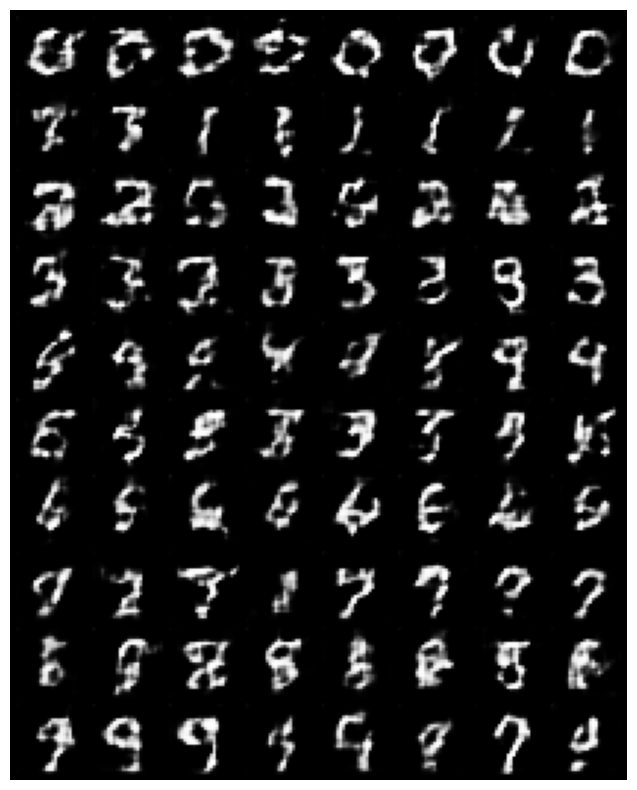

Epoch [2/20]                Batch 1875/1875 Discriminator Loss: 0.6945 Generator Loss: 0.8106


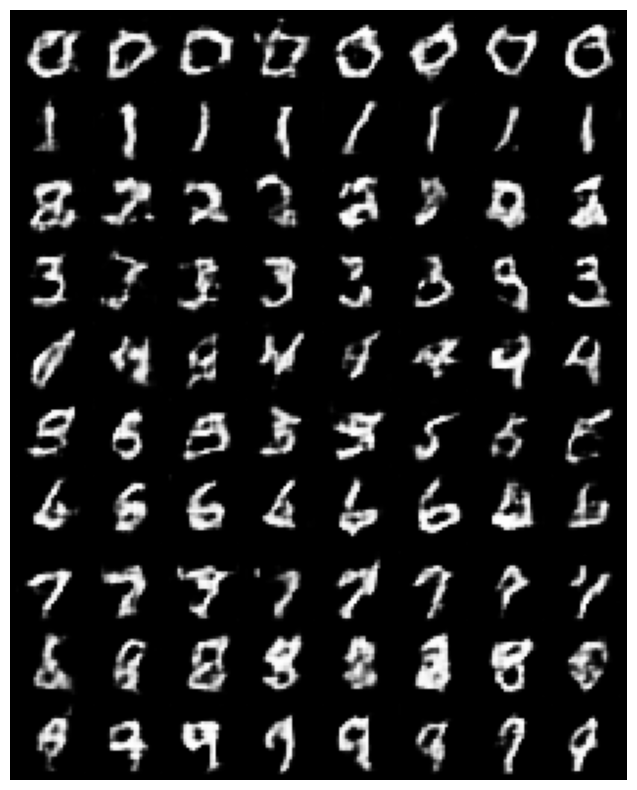

Epoch [3/20]                Batch 1875/1875 Discriminator Loss: 0.6514 Generator Loss: 0.8070


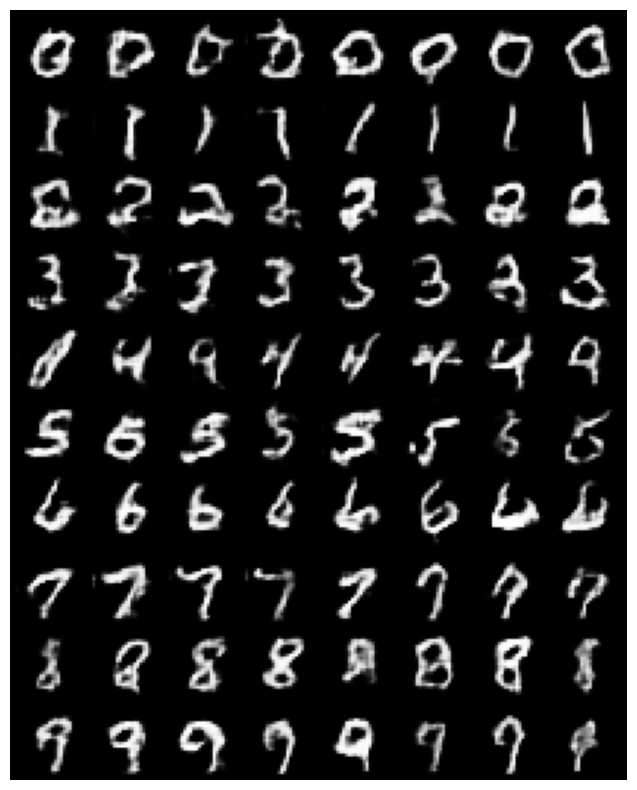

Epoch [4/20]                Batch 1875/1875 Discriminator Loss: 0.6978 Generator Loss: 0.7830


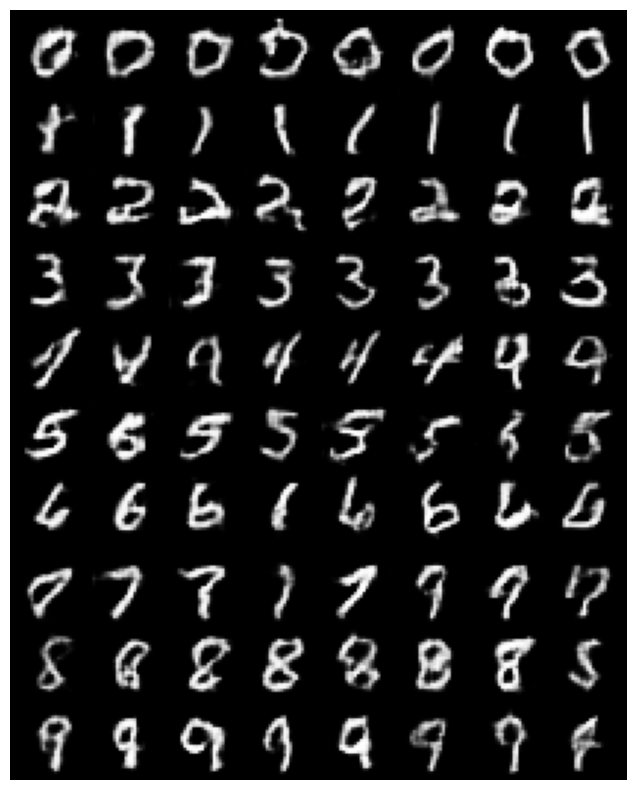

Epoch [5/20]                Batch 1875/1875 Discriminator Loss: 0.7233 Generator Loss: 0.7683


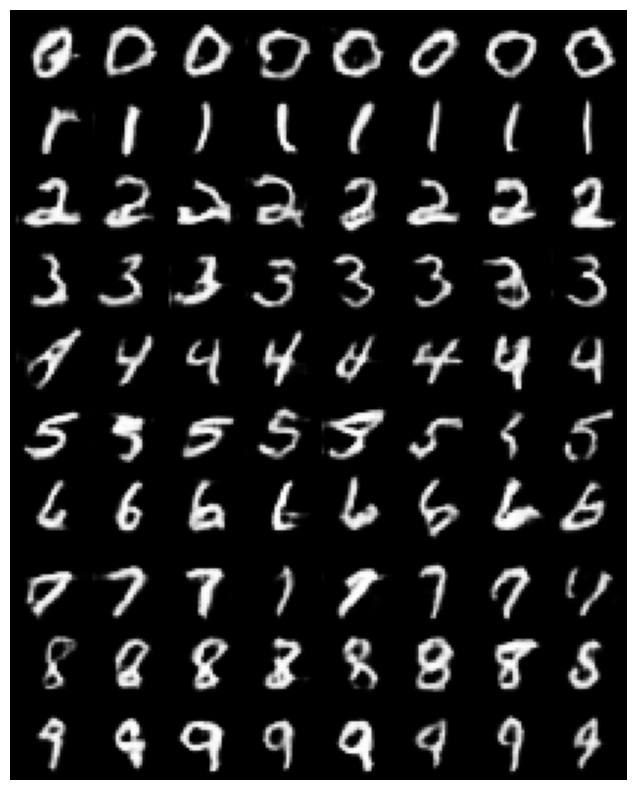

Epoch [6/20]                Batch 1875/1875 Discriminator Loss: 0.6986 Generator Loss: 0.6737


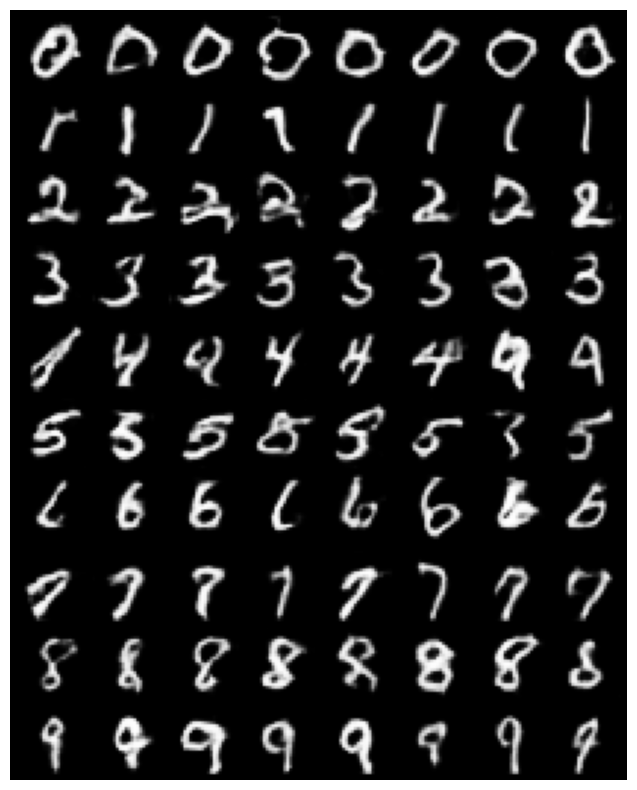

Epoch [7/20]                Batch 1875/1875 Discriminator Loss: 0.6926 Generator Loss: 0.7340


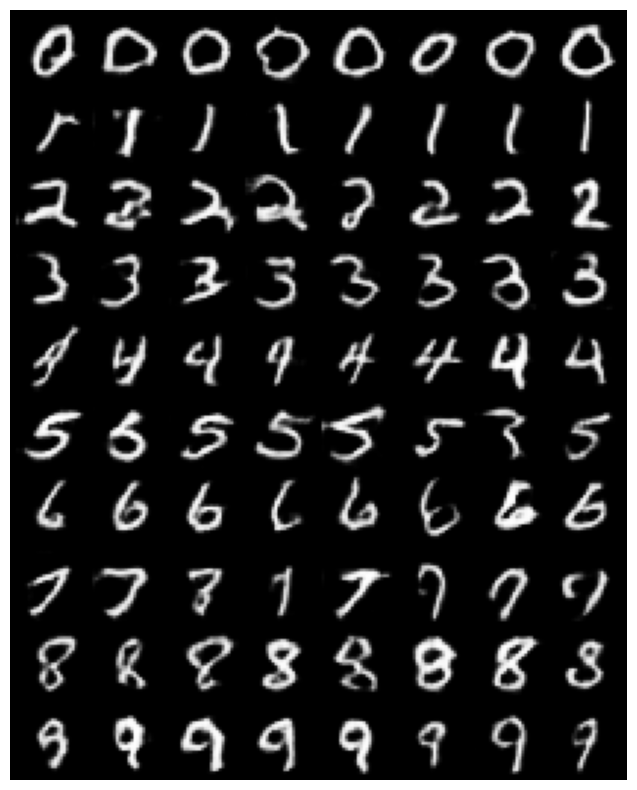

Epoch [8/20]                Batch 1875/1875 Discriminator Loss: 0.6640 Generator Loss: 0.7525


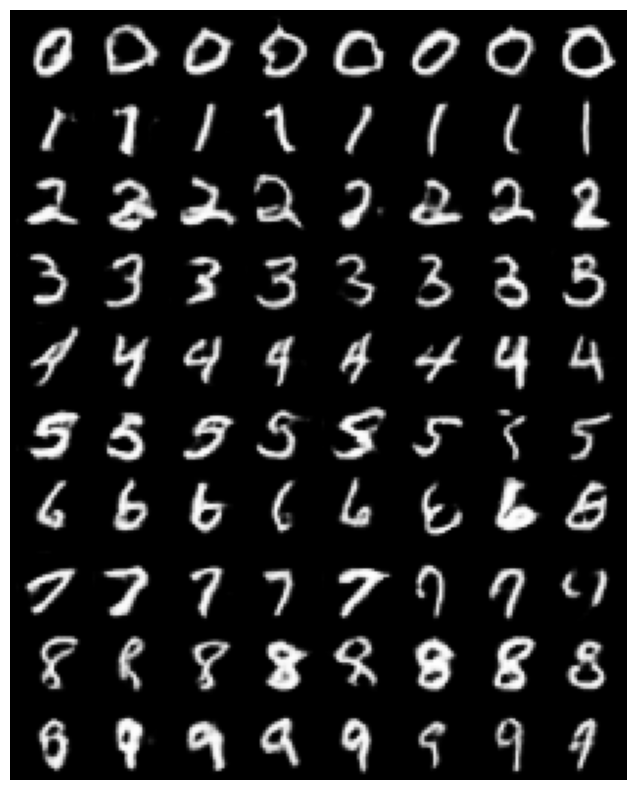

Epoch [9/20]                Batch 1875/1875 Discriminator Loss: 0.7588 Generator Loss: 0.7272


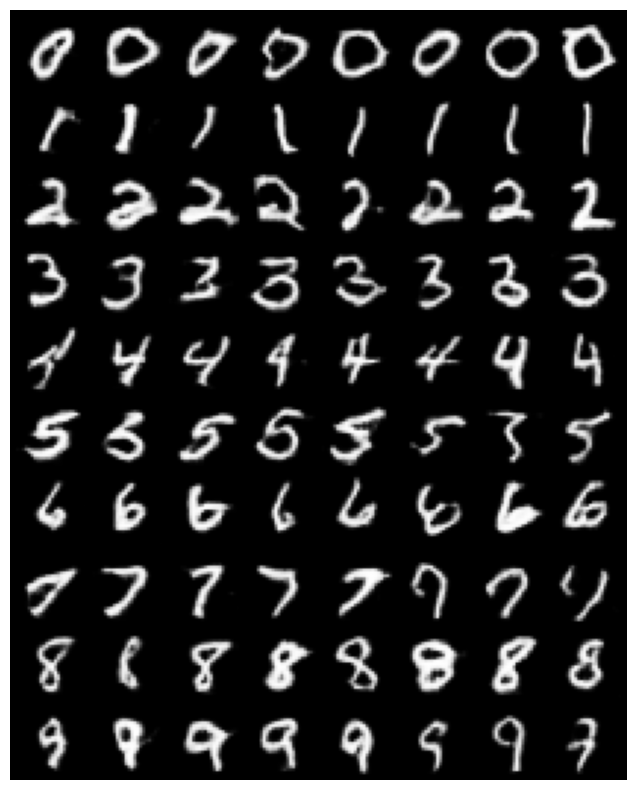

Epoch [10/20]                Batch 1875/1875 Discriminator Loss: 0.6369 Generator Loss: 0.7989


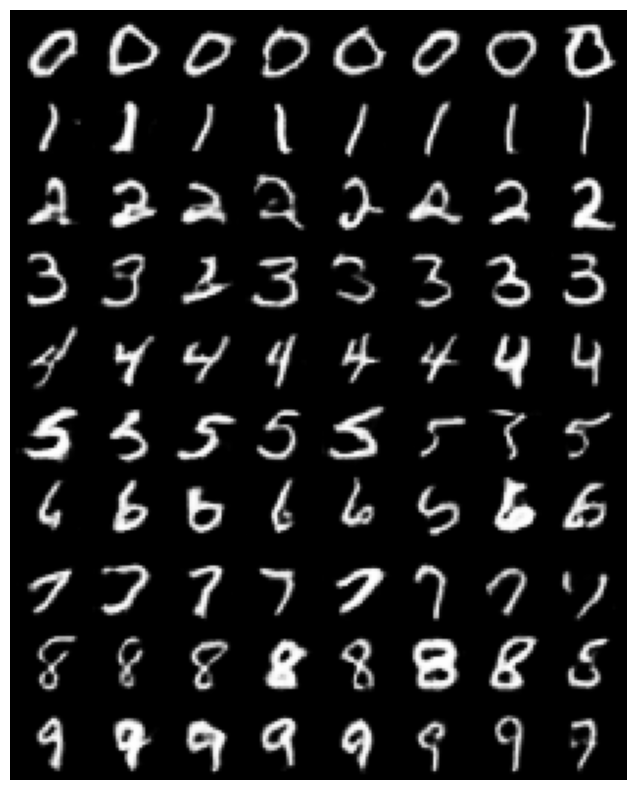

Epoch [11/20]                Batch 1875/1875 Discriminator Loss: 0.7356 Generator Loss: 0.7138


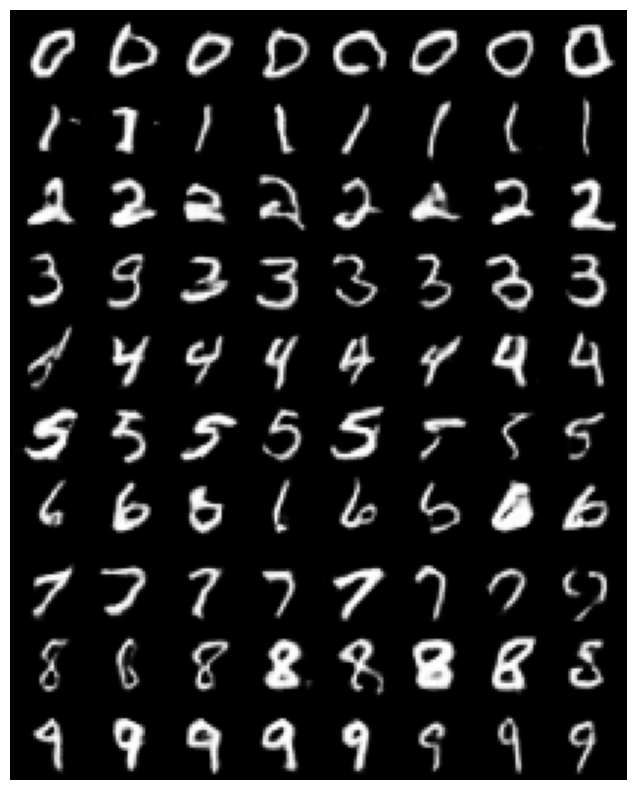

Epoch [12/20]                Batch 1875/1875 Discriminator Loss: 0.6065 Generator Loss: 0.7110


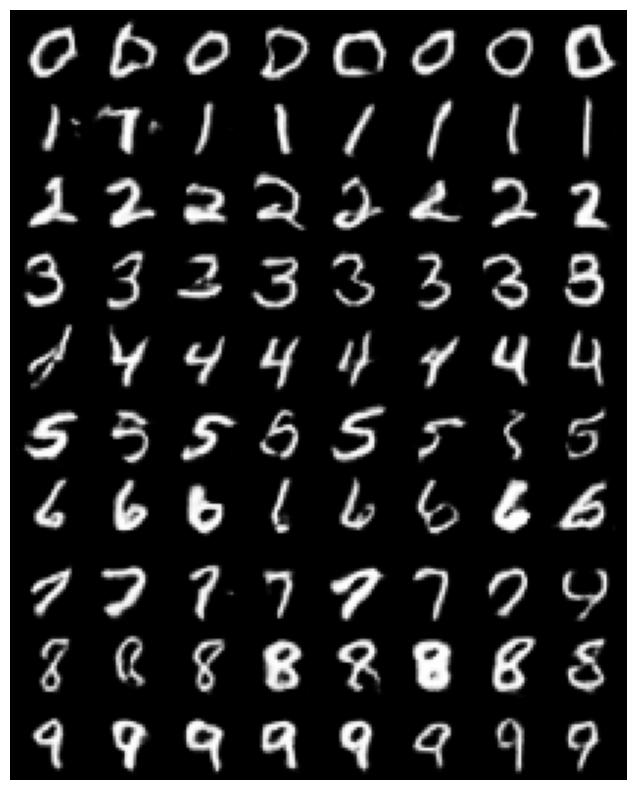

Epoch [13/20]                Batch 1875/1875 Discriminator Loss: 0.6156 Generator Loss: 0.8859


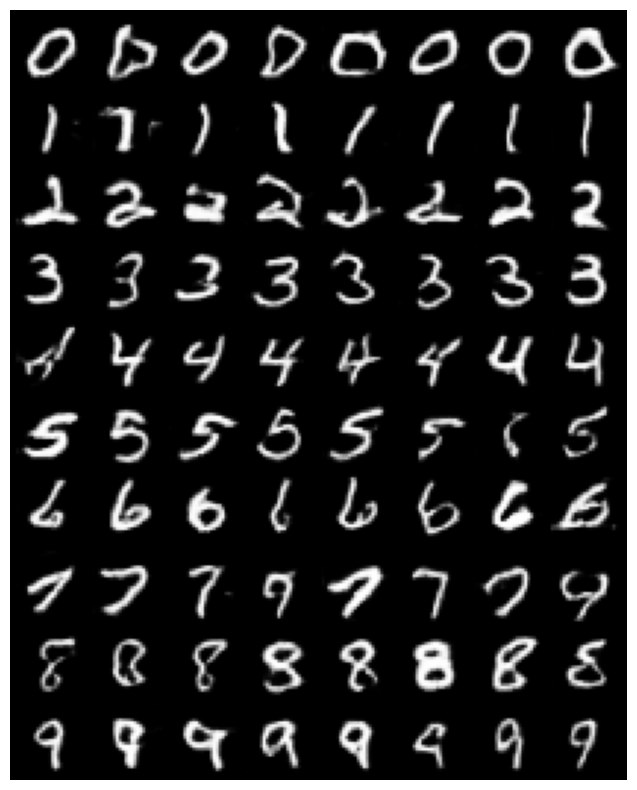

Epoch [14/20]                Batch 1875/1875 Discriminator Loss: 0.6610 Generator Loss: 0.7832


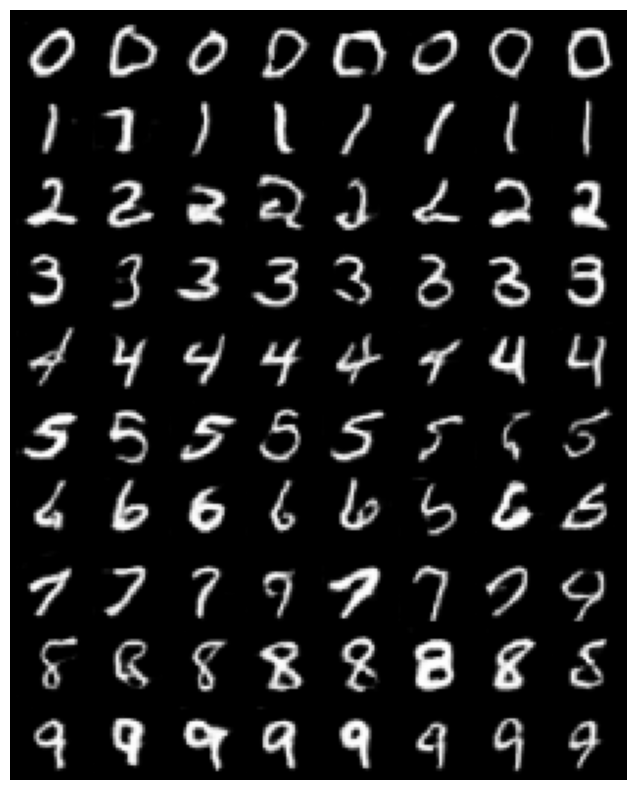

Epoch [15/20]                Batch 1875/1875 Discriminator Loss: 0.6845 Generator Loss: 0.7204


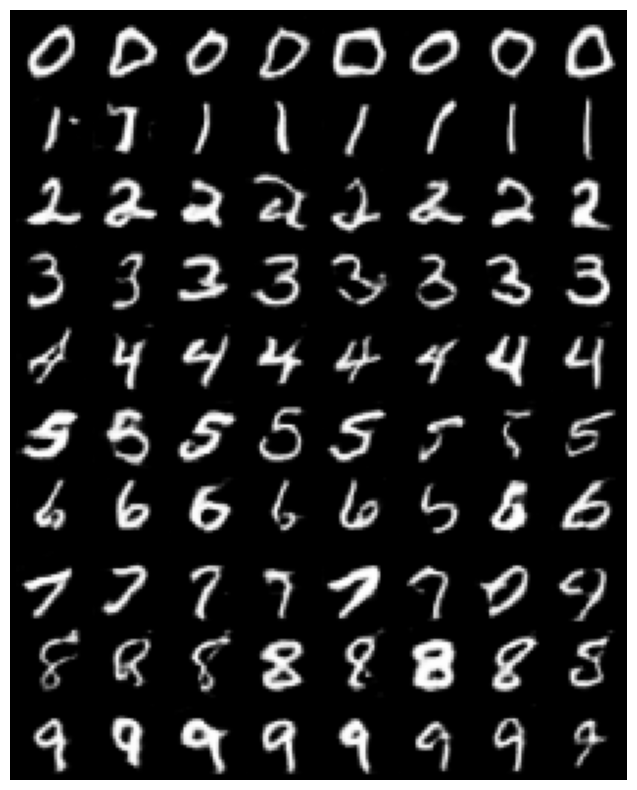

Epoch [16/20]                Batch 1875/1875 Discriminator Loss: 0.6635 Generator Loss: 0.7226


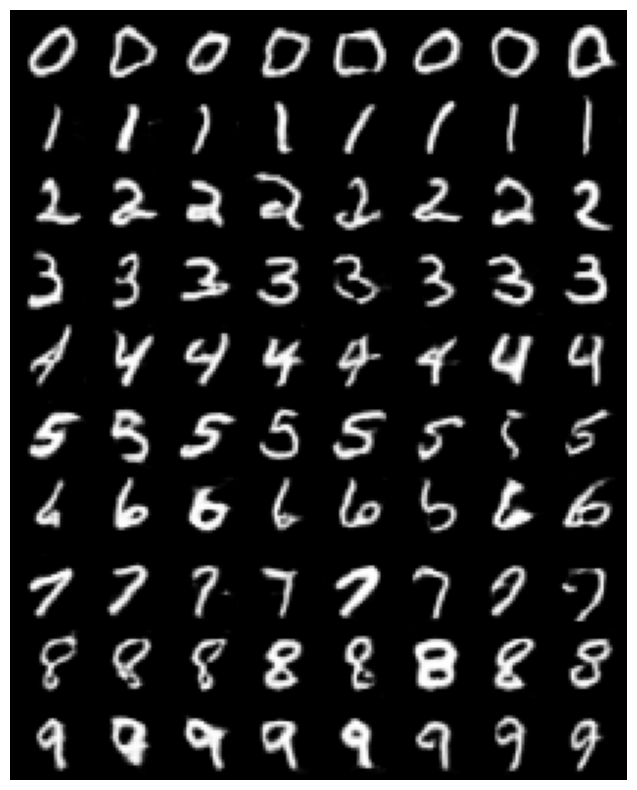

Epoch [17/20]                Batch 1875/1875 Discriminator Loss: 0.7084 Generator Loss: 0.6892


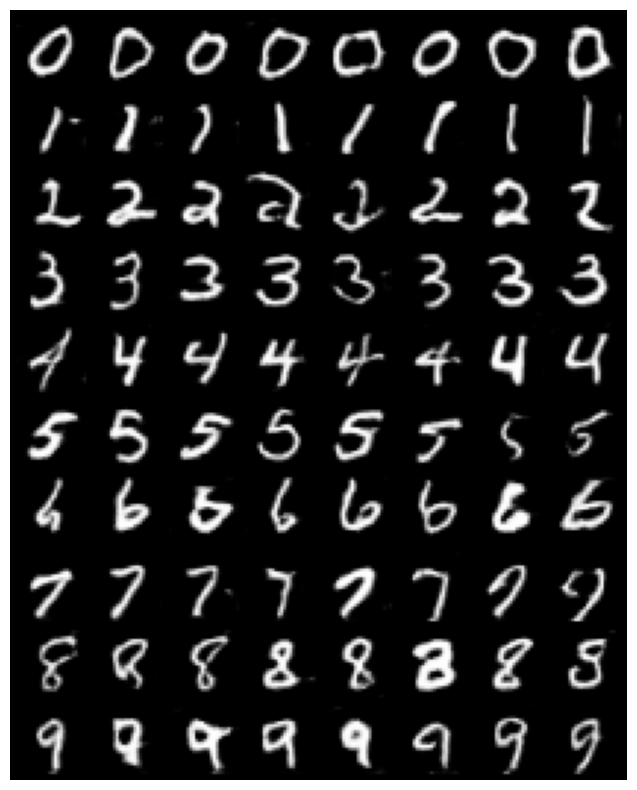

Epoch [18/20]                Batch 1875/1875 Discriminator Loss: 0.6969 Generator Loss: 0.7835


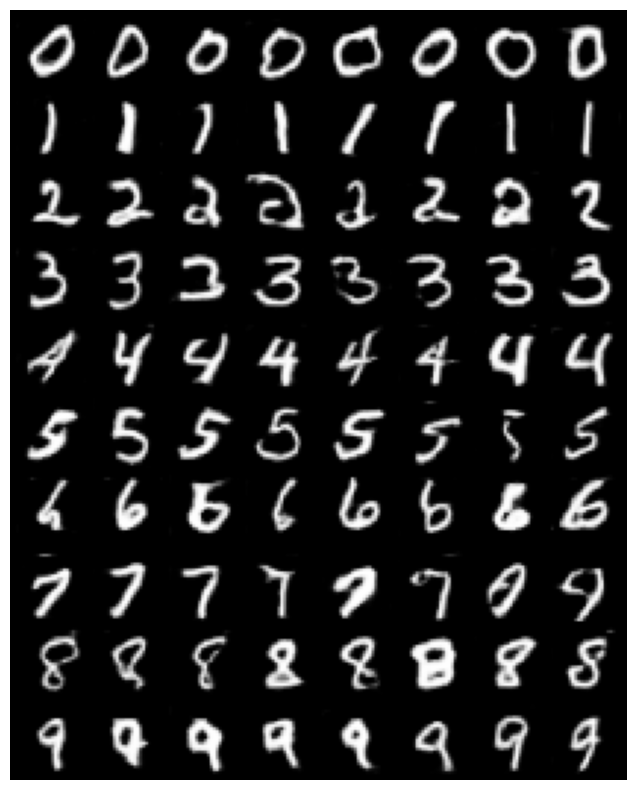

Epoch [19/20]                Batch 1875/1875 Discriminator Loss: 0.6846 Generator Loss: 0.6337


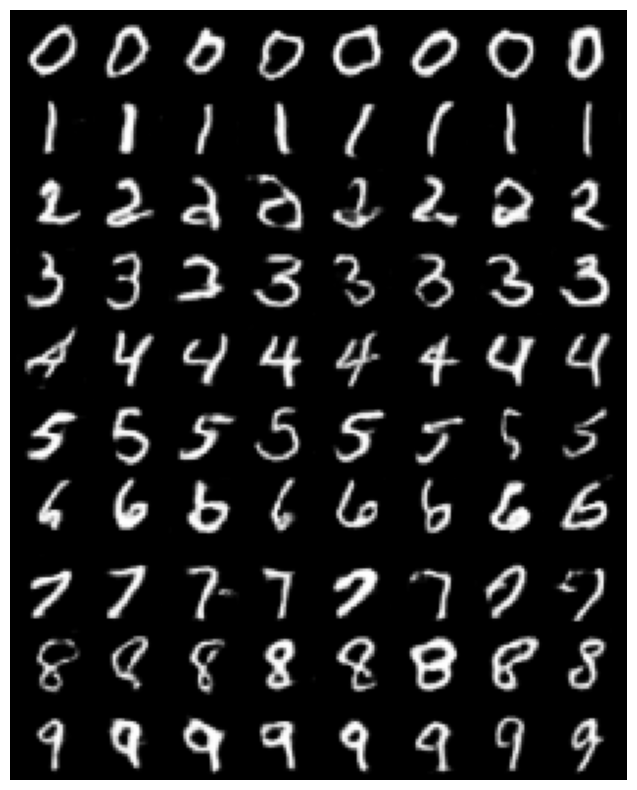

Epoch [20/20]                Batch 1875/1875 Discriminator Loss: 0.6933 Generator Loss: 0.6923


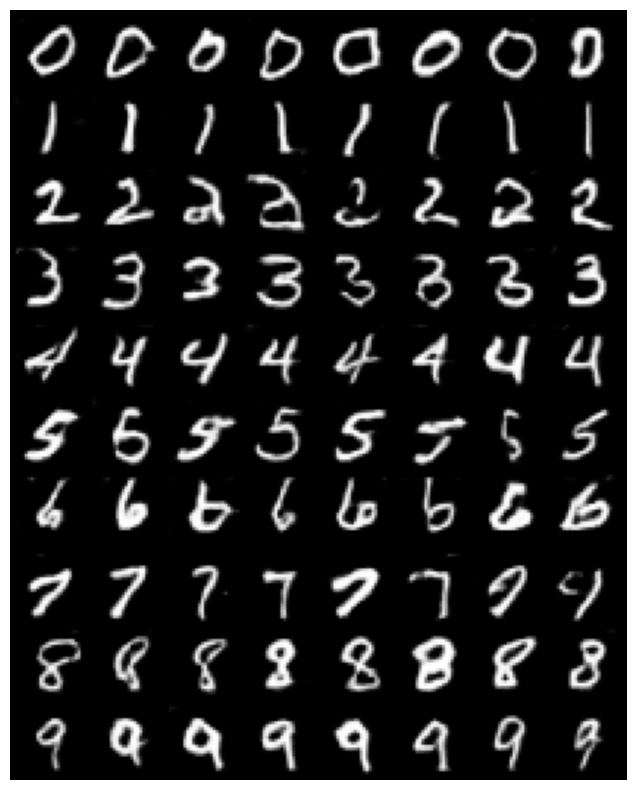

In [7]:
all_labels=torch.eye(num_classes,device=device)
fixed_noise=torch.randn(num_classes*8,latent_dim,device=device)
fixed_labels=all_labels[[digit for digit in range(num_classes) for j in range(8)]]

for epoch in range(num_epochs):
    for i,batch in enumerate(dataloader):
        real_images=batch[0].to(device)
        labels=all_labels[batch[1].to(device)]
        valid=torch.ones(real_images.size(0),1,device=device)
        fake=torch.zeros(real_images.size(0),1,device=device)

        optimizer_D.zero_grad()
        z=torch.randn(real_images.size(0),latent_dim,device=device)
        fake_images=generator(z,labels)

        real_loss=adversarial_loss(discriminator(real_images,labels),valid)
        fake_loss=adversarial_loss(discriminator(fake_images.detach(),labels),fake)
        d_loss=(real_loss+fake_loss)/2
        d_loss.backward()
        optimizer_D.step()
    
        optimizer_G.zero_grad()
        gen_images=generator(z,labels)
        g_loss=adversarial_loss(discriminator(gen_images,labels),valid)
        g_loss.backward()
        optimizer_G.step()

    print(
        f"Epoch [{epoch+1}/{num_epochs}]\
                Batch {i+1}/{len(dataloader)} "
        f"Discriminator Loss: {d_loss.item():.4f} "
        f"Generator Loss: {g_loss.item():.4f}"
    )

    generator.eval()
    with torch.no_grad():
        generated=generator(fixed_noise,fixed_labels).cpu()
        grid=torchvision.utils.make_grid(generated,nrow=8,normalize=True)
        plt.figure(figsize=(8,10))
        plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
        plt.axis("off")
        plt.show()
    generator.train()